In [12]:
import cmdstanpy

# Point CmdStanPy at your existing local CmdStan build.
# Alternative: set a CMDSTAN environment variable and delete this line,
# to keep the machine-specific path out of committed code.
cmdstanpy.set_cmdstan_path("/Users/marobinette/cmdstan")

print("cmdstanpy", cmdstanpy.__version__)
print("cmdstan", ".".join(map(str, cmdstanpy.cmdstan_version())))

cmdstanpy 1.3.0
cmdstan 2.40


In [36]:
from pathlib import Path

# data = specifys what the model needs to fit
# parameters = everything we want to sample
# model = sampling notations
# N = throws
# k = land

stan_code = r"""
data {
  int<lower=0> N;
  int<lower=0, upper=N> K;
}
parameters {
  real<lower=0, upper=1> rho;
}
model {
  rho ~ beta(1.5, 1.5);
  K ~ binomial(N, rho);
}
"""
# stan_code = r"""
#   data {
#     int<lower=0> N;
#     array[N] real X;
#   }
#   parameters {
#     real mu;
#     real<lower=0> sigma;
#   }
#   model {
#     X ~ normal(mu, sigma);
#     mu ~ normal(0, 10);
#     sigma ~ cauchy(0, 10);
#   }
# """

stan_file = Path("globe_toss.stan")
# class_example = Path("class_example.stan")
stan_file.write_text(stan_code)
print(f"wrote {stan_file.resolve()}")

wrote /Users/marobinette/bayes/globe_toss.stan


In [37]:
from cmdstanpy import CmdStanModel

# Compiles the model to a native executable (cached after the first run),
# then samples. Same arguments as the Colab notebook so the run matches.
model = CmdStanModel(stan_file=str(stan_file.resolve()))
X = [1.0, 2.0, 3.0, 4.0, 5.0]
fit = model.sample(
    data={"N": 7, "K": 3},
    # data={"N": len(X), "X": X},

    chains=2, # collection of samples from the posterior distribution
    parallel_chains=2,
    iter_warmup=250,
    iter_sampling=250,
    seed=6300,
    show_progress=False,
)

print("Stan screen test passed.")

18:40:23 - cmdstanpy - INFO - compiling stan file /Users/marobinette/bayes/globe_toss.stan to exe file /Users/marobinette/bayes/globe_toss
18:40:29 - cmdstanpy - INFO - compiled model executable: /Users/marobinette/bayes/globe_toss
18:40:30 - cmdstanpy - INFO - CmdStan start processing
18:40:30 - cmdstanpy - INFO - Chain [1] start processing
18:40:30 - cmdstanpy - INFO - Chain [2] start processing
18:40:30 - cmdstanpy - INFO - Chain [1] done processing
18:40:30 - cmdstanpy - INFO - Chain [2] done processing


Stan screen test passed.


In [ ]:
# # The screen test only proves it ran. Now look at the actual answer.
# # Prior beta(1.5, 1.5) + data (N=7, K=3) has an exact posterior:
# #   beta(1.5 + 3, 1.5 + 4) = beta(4.5, 5.5), mean = 4.5 / 10 = 0.45
# print(fit.summary().loc[["rho"]])

# draws = fit.stan_variable("rho")
# print(f"\nposterior mean of rho: {draws.mean():.3f}   (exact: 0.450)")
# print(f"P(rho > 0.5)         : {(draws > 0.5).mean():.3f}")

         Mean      MCSE    StdDev       MAD        5%       50%       95%  \
rho  0.434629  0.010406  0.148728  0.170126  0.193715  0.431061  0.672087   

     ESS_bulk  ESS_tail  ESS_bulk/s    R_hat  
rho   206.717   238.281     41343.4  1.01974  

posterior mean of rho: 0.435   (exact: 0.450)
P(rho > 0.5)         : 0.334


array([[<Axes: title={'center': 'rho'}>, <Axes: title={'center': 'rho'}>]],
      dtype=object)

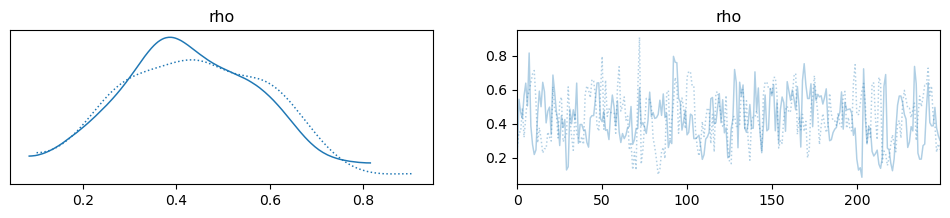

In [32]:
import arviz as az
az_fit = az.from_cmdstanpy(fit)

# az.plot_trace(az_fit, var_names=["mu", "sigma"])
az.plot_trace(az_fit, var_names=["rho"])